# Fáze 5b: Experiment s šumem (ML vs. pravidla)

In [1]:
import os, sys
from pathlib import Path

_PROJECT_ROOT = (
    Path(os.path.abspath("")).parent
    if Path(os.path.abspath("")).name == "notebooks"
    else Path(os.path.abspath(""))
)
os.chdir(_PROJECT_ROOT)
sys.path.insert(0, str(_PROJECT_ROOT))

import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
print("Setup OK")

Setup OK


## 1. Načtení výsledků experimentu

In [2]:
RESULTS_DIR = Path("results/phase5b_noise")

raw_df = pd.read_csv(RESULTS_DIR / "noise_experiment_raw.csv")
summary_df = pd.read_csv(RESULTS_DIR / "noise_experiment_summary.csv")

MODEL_NAMES = {"dt": "Decision Tree", "rf": "Random Forest", "xgb": "XGBoost"}

print(f"Raw v\u00fdsledky: {len(raw_df)} \u0159\u00e1dk\u016f")
print(f"Summary: {len(summary_df)} \u0159\u00e1dk\u016f")
raw_df.head()

Raw výsledky: 45 řádků
Summary: 12 řádků


,noise_level,seed,model,accuracy,f1_macro,train_time_s,best_params,f1_shelf_picking,f1_front_zone_bin,f1_special_zone,f1_floor_block,f1_pallet_rack,denoising_gain
0,0.1,42,dt,0.972231,0.966266,7.583099,"{'classifier__max_depth': 10, 'classifier__min...",0.983413,0.981651,0.934279,0.964055,0.967930,0.072231
1,0.1,42,rf,0.978149,0.976833,39.386304,"{'classifier__max_depth': 20, 'classifier__min...",0.983656,0.980541,0.957746,0.973123,0.989098,0.078149
2,0.1,42,xgb,0.981942,0.981273,25.743549,"{'classifier__learning_rate': 0.05, 'classifie...",0.986611,0.983784,0.963544,0.982326,0.990099,0.081942
3,0.1,123,dt,0.975417,0.972335,2.676116,"{'classifier__max_depth': 10, 'classifier__min...",0.981651,0.981887,0.950652,0.977612,0.969874,0.075417
4,0.1,123,rf,0.977542,0.975789,35.555102,"{'classifier__max_depth': 20, 'classifier__min...",0.983289,0.980857,0.955744,0.973978,0.985075,0.077542


## 2. Přehled výsledků. Denoising Gain

- Gain > 0 -> model se naučil odšumět
- Gain = 0 -> model pouze kopíruje zašuměné labely
- Gain < 0 -> model je horší než náhodné přeházení

In [3]:
display_df = summary_df.copy()
display_df["model"] = display_df["model"].map(MODEL_NAMES)
display_df["noise_pct"] = (display_df["noise_level"] * 100).astype(int).astype(str) + " %"

pivot = display_df.pivot(
    index="model", columns="noise_pct",
    values="denoising_gain_mean"
)[["0 %", "10 %", "15 %", "20 %"]]

pivot_styled = pivot.style.format("{:.4f}").background_gradient(
    cmap="Greens", axis=None, vmin=0
).set_caption("Denoising Gain (pr\u016fm\u011br p\u0159es 5 seed\u016f)")

display(pivot_styled)

noise_pct,0 %,10 %,15 %,20 %
model,,,,
Decision Tree,-0.0193,0.0741,0.1225,0.1674
Random Forest,-0.0178,0.0784,0.1278,0.1760
XGBoost,-0.0135,0.0807,0.1289,0.1783


## 3. Denoising Gain

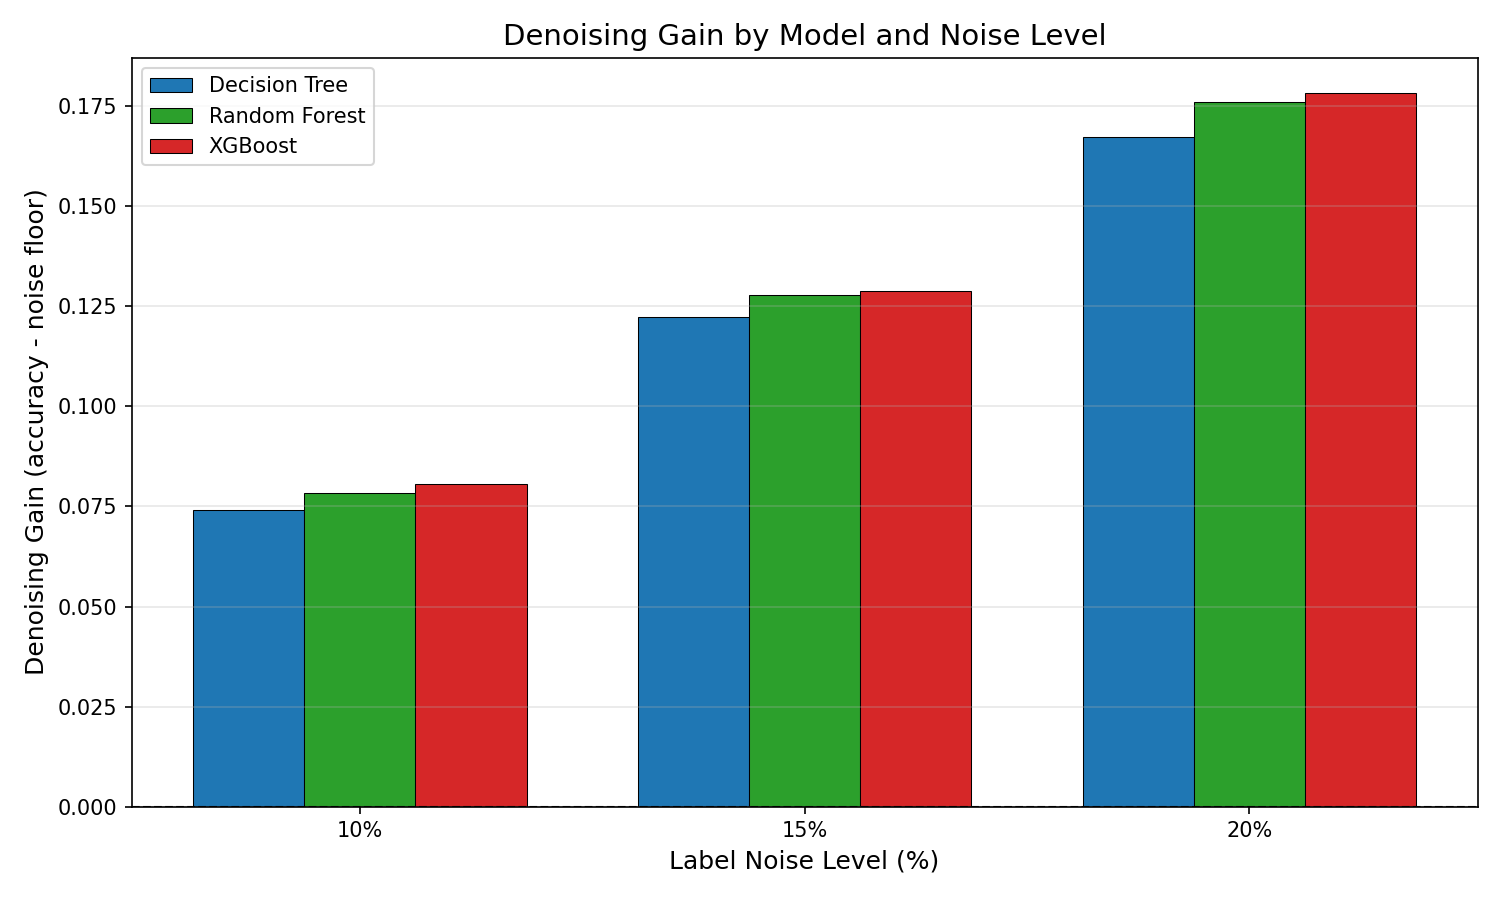

In [4]:
display(Image(filename=str(RESULTS_DIR / "noise_denoising_gain.png")))

## 4. Degradace F1 macro


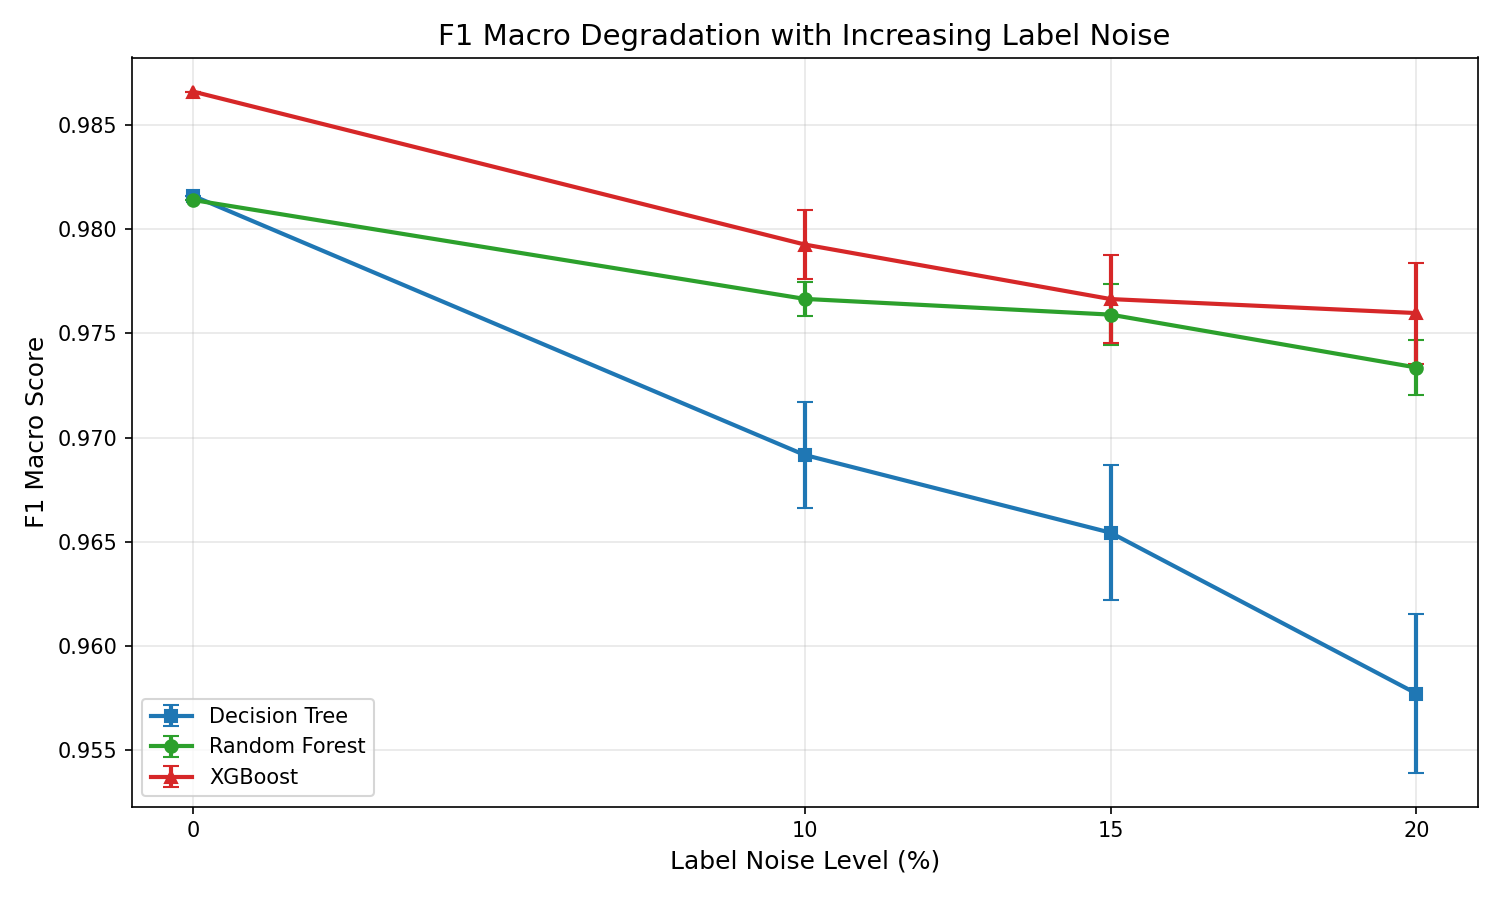

In [5]:
display(Image(filename=str(RESULTS_DIR / "noise_f1_degradation.png")))

## 5. analýza pro kazdou třidu pomoci F1-skóre

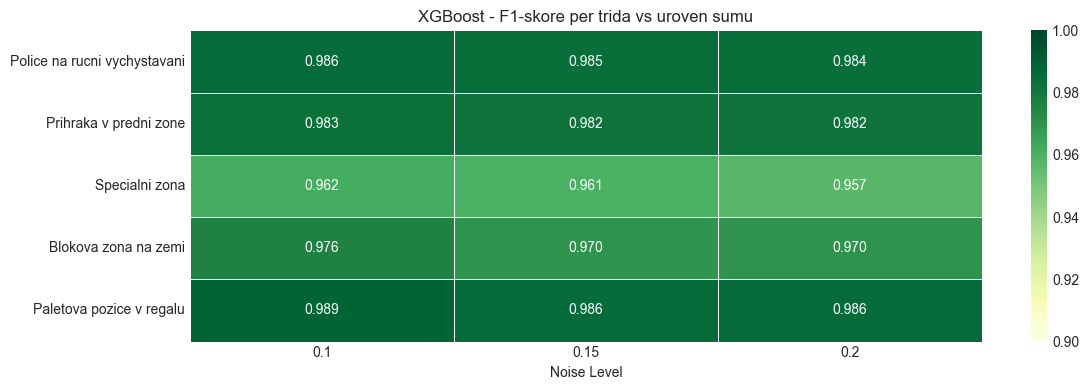

In [6]:
f1_cols = [c for c in raw_df.columns if c.startswith("f1_") and c != "f1_macro"]

CLASS_LABELS = {
    "f1_shelf_picking": "Police na rucni vychystavani",
    "f1_front_zone_bin": "Prihraka v predni zone",
    "f1_special_zone": "Specialni zona",
    "f1_floor_block": "Blokova zona na zemi",
    "f1_pallet_rack": "Paletova pozice v regalu",
}

xgb_data = raw_df[raw_df["model"] == "xgb"].groupby("noise_level")[f1_cols].mean()
xgb_data.columns = [CLASS_LABELS.get(c, c) for c in xgb_data.columns]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    xgb_data.T, annot=True, fmt=".3f", cmap="YlGn",
    linewidths=0.5, ax=ax, vmin=0.90, vmax=1.0
)
ax.set_xlabel("Noise Level")
ax.set_title("XGBoost - F1-skore per trida vs uroven sumu")
plt.tight_layout()
plt.show()